In [ ]:
from gradio.monitoring_dashboard import total_requests
from rich.jupyter import display
from timm.models.swin_transformer_v2_cr import init_weights
from torch.amp import custom_bwd
from torch.nn.functional import threshold
from transformers.models.x_clip.modeling_x_clip import x_clip_loss
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
from image_utils import ImageUtils
from dino_detector import DinoDetector
from clip_classifier import ClipClassifier
from core.models import RegionPrompt
from image_utils import ImageUtils
from core.constants import Constants
from core.plot_utils import PlotUtils
from core.constants import Constants
from core.depth import Depth
import numpy as np
import load_logging

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

GROUNDING_PROMPT = (
    "food, meal, cooked food, dish, plate, bowl, wooden plate, ceramic plate, "
    "cup, knife, spoon, sauce, meat, cheese, "
    "garnish, accent, leaf, herb, fresh, verde, aroma, botanical, greenery, "
    "sprig, essence, finish, touch, crown, detail"
)

BOX_THRESHOLD = 0.30
TEXT_THRESHOLD = 0.30

# sam
SAM_CHECKPOINT = "checkpoints/sam_vit_b_01ec64.pth"
SAM_MODEL_TYPE = "vit_b"

In [ ]:
from loaders_beta import load_openclip, load_grounding_dino, load_sam, load_depth_anything_v2

# load checkpoints
dino_model = load_grounding_dino()
sam_predictor = load_sam(SAM_CHECKPOINT, SAM_MODEL_TYPE, device=DEVICE)
depth_anything_model = load_depth_anything_v2(device=DEVICE)

# create objects
dino_detector = DinoDetector(
    device=DEVICE,
    model=dino_model
)

In [21]:
# image
image_path = "photos/wood_dish_1.png"
# image_path = "photos/out_screen1.png"
# image_path = "photos/ok_light_2.png"
# image_path = "photos/bad_light_1.png"
# image_path = "photos/good_light_1.png"
# # image_path = "photos/bad_light_2.png"
# # image_path = "photos/non_subject_items_in_range.png"
# # image_path = "photos/horizontal_angle.png"
# # image_path = "photos/horizontal_angle_2.png"
image_path = "photos/horizontal_3.png"
# image_path = "photos/horizontal_4.png"
# image_path = "photos/horizontal_5.png"

# detect objects
image_source, image, boxes, phrases = dino_detector.detect_boxes(
    image_path,
    grounding_prompt=GROUNDING_PROMPT,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
)

regions: list[RegionPrompt] = []
for box, phrase in zip(boxes, phrases):
    region = RegionPrompt(box=box, label=phrase)
    regions.append(region)

pil_img = ImageUtils.convert_img_source_to_pil(image_source)

if Constants.DEBUG:
    ImageUtils.display_bounding_boxes(image_source, boxes)


In [22]:
from sam_segmenter import SamSegmenter

sam_segmenter = SamSegmenter(predictor=sam_predictor, device=DEVICE)
regions_with_masks = sam_segmenter.segment(image=ImageUtils.pil_to_numpy(pil_img), regions=regions)

# ImageUtils.display_regions_with_masks(regions_with_masks)

In [23]:
depth = depth_anything_model.infer_image(raw_image=image_source, input_size=618)
dmin = np.nanmin(depth)
dmax = np.nanmax(depth)

In [24]:
# ======== debug= ==============
# full image (scalar)
if Constants.DEBUG:
    ImageUtils.show_depth(
        depth,
        title="Depth Anything V2",
        vmin=dmin,
        vmax=dmax,
        cmap="inferno"
    )

# masked regions (scalar)
if Constants.DEBUG:
    for region in regions_with_masks:
        PlotUtils.show_mask_depth_with_center_distance(
            mask=region.mask, image_source_depth=depth,
            title=region.label, vmin=dmin, vmax=dmax, region_label=region.label, region_box=region.box)

In [25]:
norm_depth = Depth.normalize_depth(depth, vmin=dmin, vmax=dmax)
main_dish = Depth.compute_main_dish(depth, regions_with_masks, image_source)

init_threshold: 0.6
1: curr_threshold: 0.2937086119116698
depth coverage: 31.023456960519486
2: curr_threshold: 0.09458327965666952
depth coverage: 49.210231176197716
3: curr_threshold: 0.03045874866380214
depth coverage: 49.210231176197716
4: curr_threshold: 0.007481794630329398
depth coverage: 60.97062742876294
5: curr_threshold: 0.0018378053382393361
depth coverage: 60.97062742876294
6: curr_threshold: 0.00045143292861438773
depth coverage: 60.97062742876294
7: curr_threshold: 0.00011088861523963167
depth coverage: 60.97062742876294
8: curr_threshold: 2.723834308566027e-05
depth coverage: 60.97062742876294
9: curr_threshold: 6.690743972668632e-06
depth coverage: 60.97062742876294
10: curr_threshold: 1.6434940542095192e-06
depth coverage: 60.97062742876294


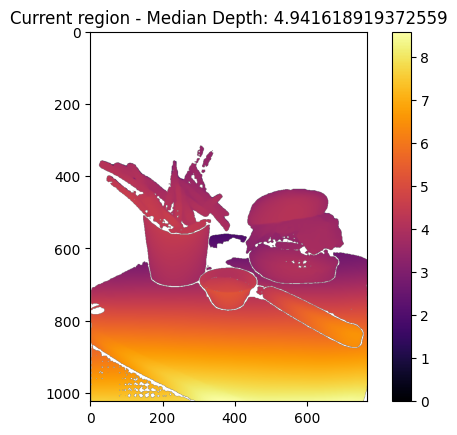

In [26]:
from core.math import Math

init_support_threshold = 0.6
reduction_rate = 0.9
curr_threshold = init_support_threshold
attempt = 1
max_attempts = 10
min_increase = 0.6
prev_percentage = None
had_significant_increase = False

print(f"init_threshold: {curr_threshold}")
curr_region = None

while attempt <= max_attempts:
    subject_regions = Depth.get_supported_subject_regions(
        depth=depth,
        main_dish=main_dish,
        regions_with_masks=regions_with_masks,
        support_threshold=curr_threshold,
        dmin=dmin,
        dmax=dmax,
    )

    if not subject_regions:
        print(f"{attempt}: no supported regions, stopping")
        break

    curr_region = Depth.merge_regions_mask(subject_regions)

    curr_percentage = Depth.compute_depth_in_range(
        depth,
        curr_region.mask
    )

    if prev_percentage is not None and prev_percentage > 0:
        increase = (curr_percentage - prev_percentage) / prev_percentage
        if increase >= min_increase:
            had_significant_increase = True
        elif had_significant_increase:
            print(f"{attempt}: depth increase below threshold, stopping")
            break

    criterion = curr_percentage / 100.0
    curr_threshold = Math.exp_decay(
        start_threshold=curr_threshold,
        criterion=criterion,
        reduction_rate=reduction_rate
    )

    print(f"{attempt}: curr_threshold: {curr_threshold}")
    print(f"depth coverage: {curr_percentage}")

    prev_percentage = curr_percentage
    attempt += 1

if curr_region is not None:
    ImageUtils.show_mask_depth(
        mask=curr_region.mask,
        image_source_depth=depth,
        vmin=dmin,
        vmax=dmax,
        title=f"Current region"
    )
